In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV, learning_curve
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, accuracy_score
import warnings
warnings.filterwarnings("ignore")

In [3]:
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name='target')

print(X.shape[0])
print(X.shape[1])
print(np.unique(y))
print(X.describe())

569
30
[0 1]
       mean radius  mean texture  mean perimeter    mean area  \
count   569.000000    569.000000      569.000000   569.000000   
mean     14.127292     19.289649       91.969033   654.889104   
std       3.524049      4.301036       24.298981   351.914129   
min       6.981000      9.710000       43.790000   143.500000   
25%      11.700000     16.170000       75.170000   420.300000   
50%      13.370000     18.840000       86.240000   551.100000   
75%      15.780000     21.800000      104.100000   782.700000   
max      28.110000     39.280000      188.500000  2501.000000   

       mean smoothness  mean compactness  mean concavity  mean concave points  \
count       569.000000        569.000000      569.000000           569.000000   
mean          0.096360          0.104341        0.088799             0.048919   
std           0.014064          0.052813        0.079720             0.038803   
min           0.052630          0.019380        0.000000             0.000000

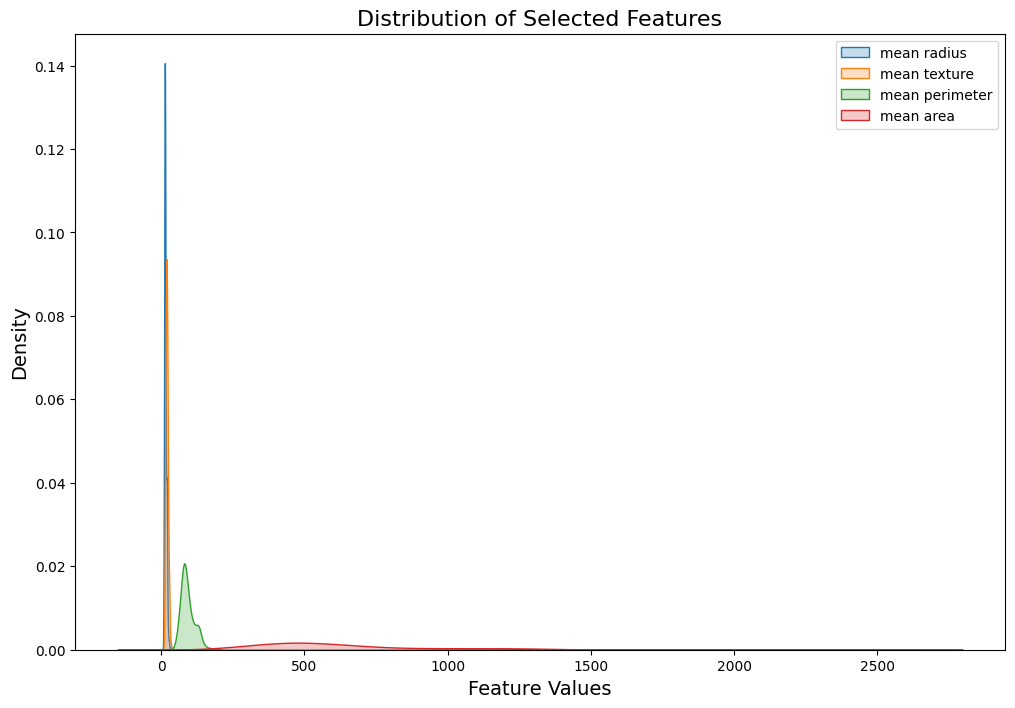

In [5]:
plt.figure(figsize=(12, 8))
features_to_plot = ['mean radius', 'mean texture', 'mean perimeter', 'mean area']
for feature in features_to_plot:
    sns.kdeplot(X[feature], shade=True, label=feature)
plt.title("Distribution of Selected Features", fontsize=16)
plt.xlabel("Feature Values", fontsize=14)
plt.ylabel("Density", fontsize=14)
plt.legend()
plt.show()

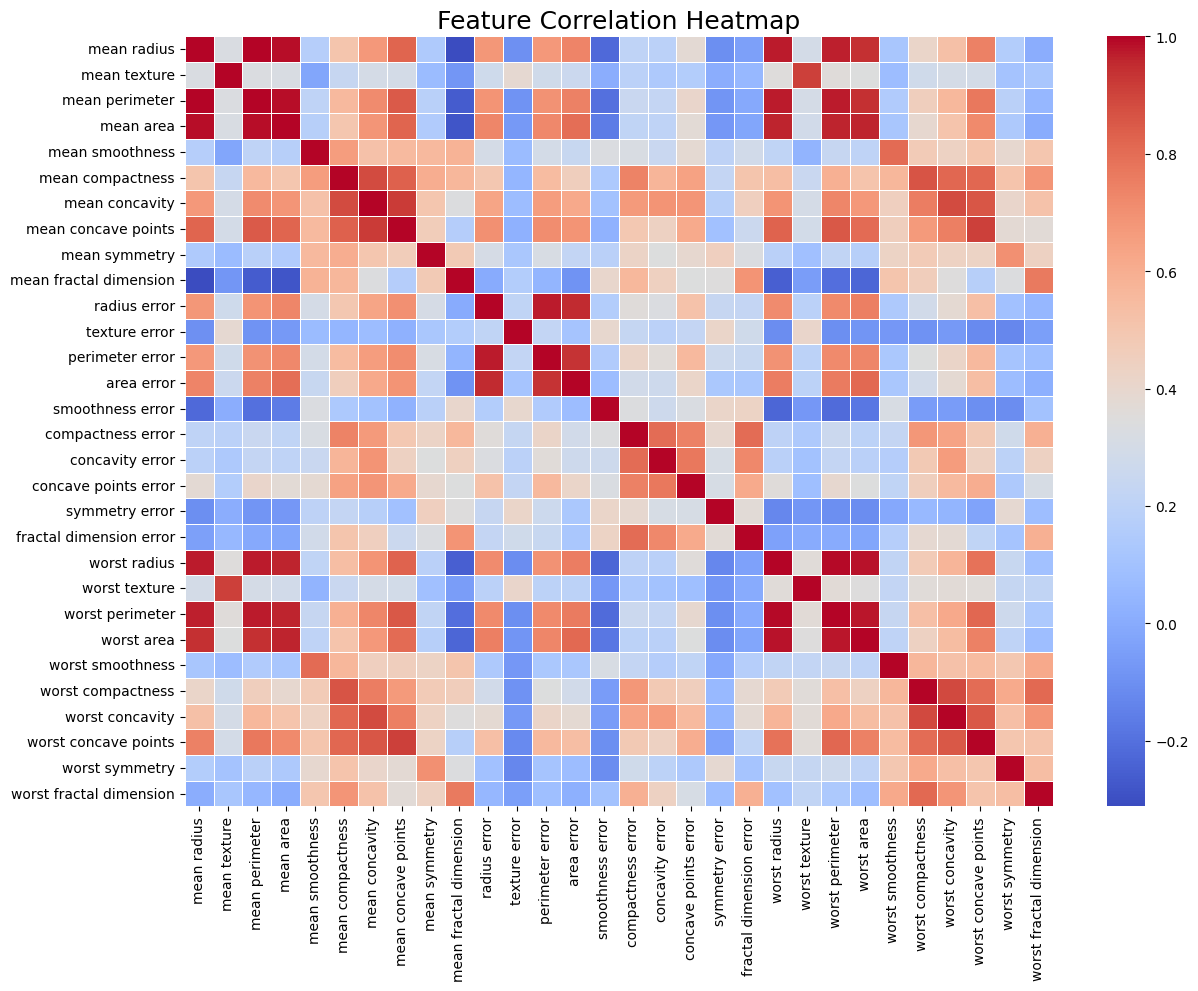

In [6]:
plt.figure(figsize=(14, 10))
corr = X.corr()
sns.heatmap(corr, annot=False, cmap='coolwarm', linewidths=.5)
plt.title("Feature Correlation Heatmap", fontsize=18)
plt.show()

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

etc = ExtraTreesClassifier(random_state=42)
etc.fit(X_train, y_train)

y_pred = etc.predict(X_test)
print(classification_report(y_test, y_pred))
print(accuracy_score(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      0.94      0.96        64
           1       0.96      0.99      0.98       107

    accuracy                           0.97       171
   macro avg       0.97      0.96      0.97       171
weighted avg       0.97      0.97      0.97       171

0.9707602339181286


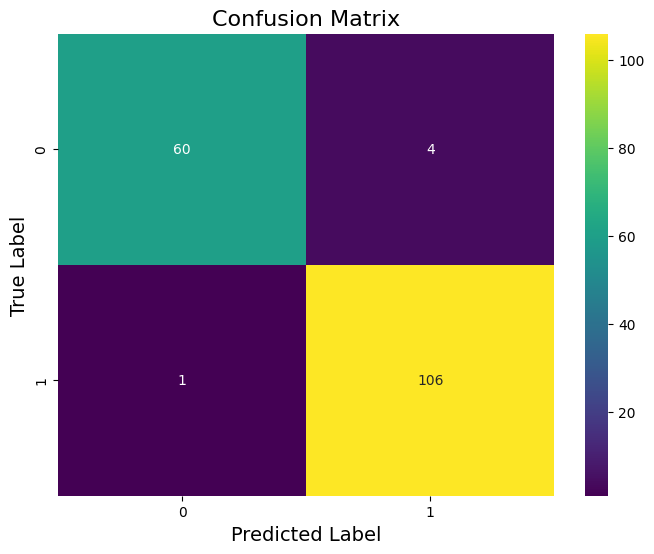

In [8]:
conf_mat = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='viridis', cbar=True)
plt.xlabel("Predicted Label", fontsize=14)
plt.ylabel("True Label", fontsize=14)
plt.title("Confusion Matrix", fontsize=16)
plt.show()

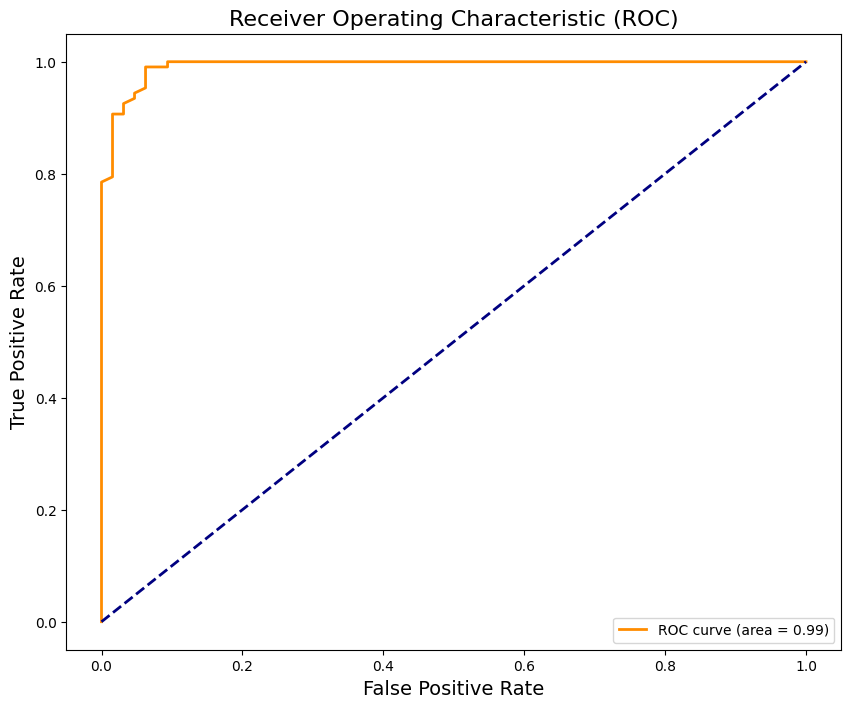

In [9]:
# 计算预测概率
y_proba = etc.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

# 绘制 ROC 曲线
plt.figure(figsize=(10, 8))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate', fontsize=14)
plt.ylabel('True Positive Rate', fontsize=14)
plt.title('Receiver Operating Characteristic (ROC)', fontsize=16)
plt.legend(loc="lower right")
plt.show()

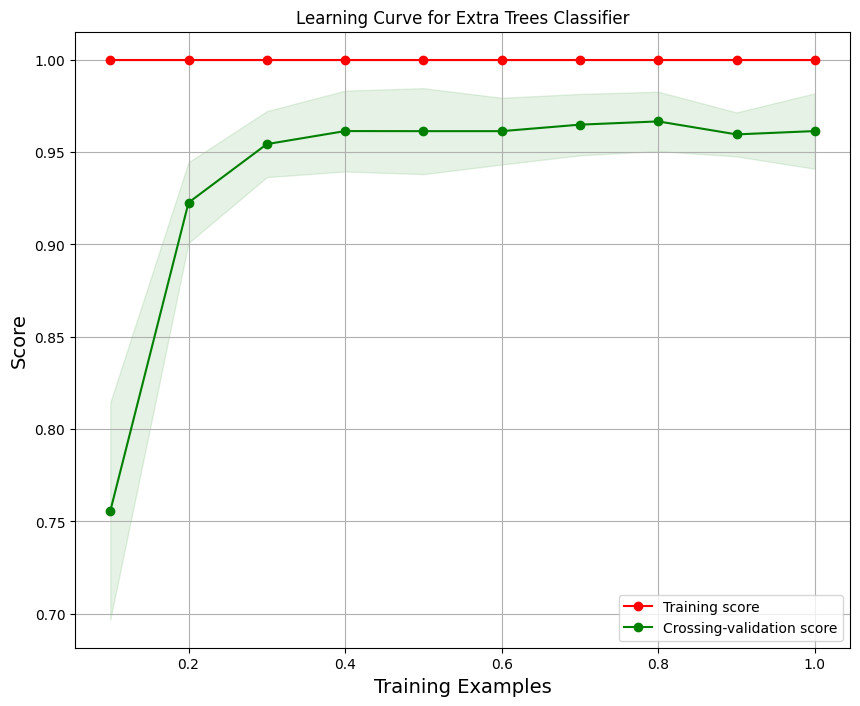

In [10]:
def plot_learning_curve(estimator, title, X, y, ylim=None, cv=5, n_jobs=-1, train_sizes=np.linspace(0.1, 1.0, 10)):
    plt.figure(figsize=(10, 8))
    plt.title(title)
    if ylim is not None:
        plt.ylim(*ylim)
    plt.xlabel("Training Examples", fontsize=14)
    plt.ylabel("Score", fontsize=14)

    training_sizes, train_scores, test_scores = learning_curve(estimator, X, y, cv=cv, n_jobs=n_jobs, train_sizes=train_sizes)
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)

    plt.grid()

    plt.fill_between(train_sizes, train_scores_mean - train_scores_std, train_scores_mean + train_scores_std, alpha=0.1, color='r')
    plt.fill_between(train_sizes, test_scores_mean - test_scores_std, test_scores_mean + test_scores_std, alpha=0.1, color='g')
    plt.plot(train_sizes, train_scores_mean, 'o-', color='r', label="Training score")
    plt.plot(train_sizes, test_scores_mean, 'o-', color='g', label='Crossing-validation score')

    plt.legend(loc="best")
    plt.show()

plot_learning_curve(etc, "Learning Curve for Extra Trees Classifier", X, y)

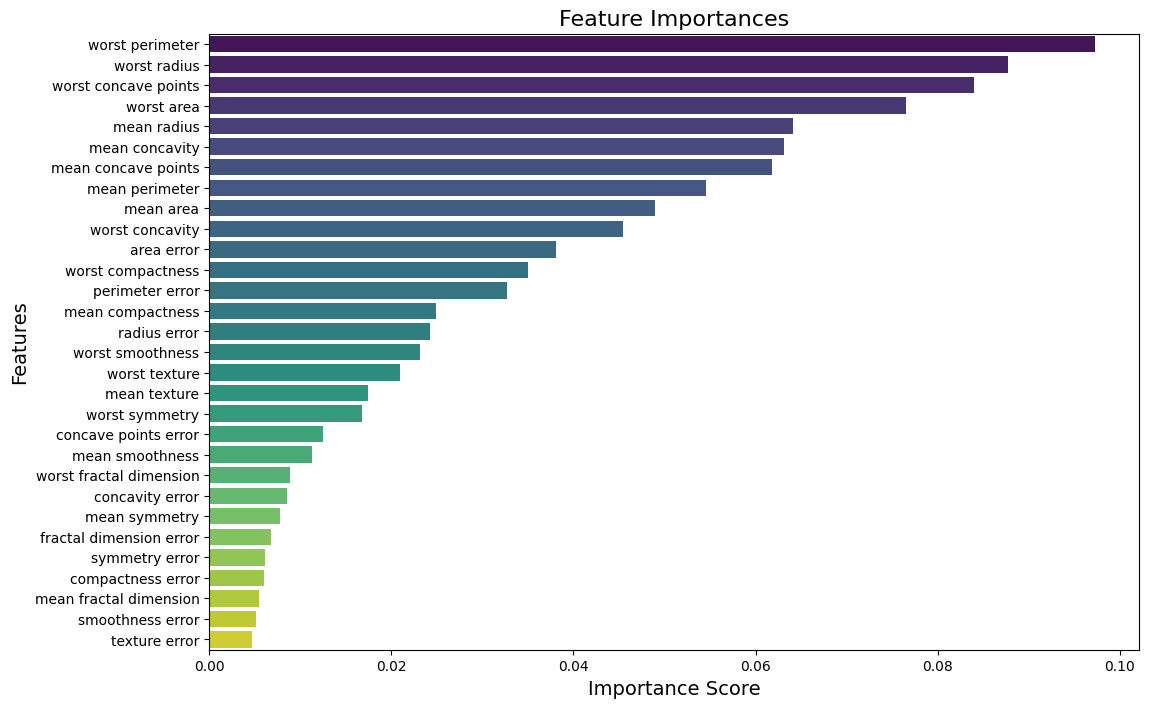

Top 10 important features:
 worst perimeter         0.097265
worst radius            0.087719
worst concave points    0.084027
worst area              0.076563
mean radius             0.064110
mean concavity          0.063129
mean concave points     0.061817
mean perimeter          0.054540
mean area               0.048923
worst concavity         0.045397
dtype: float64


In [11]:
feature_importances = pd.Series(etc.feature_importances_, index=X.columns)
feature_importances = feature_importances.sort_values(ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(x=feature_importances.values, y=feature_importances.index, palette="viridis")
plt.title("Feature Importances", fontsize=16)
plt.xlabel("Importance Score", fontsize=14)
plt.ylabel("Features", fontsize=14)
plt.show()

print("Top 10 important features:\n", feature_importances.head(10))

In [13]:
param_grid = {
    'n_estimators': [50, 100, 150],  # 决策树数量
    'max_depth': [None, 10, 20, 30],  # 决策树最大深度
    'min_samples_split': [2, 4, 6],  # 分裂内部节点所需的最小样本数
    'min_samples_leaf': [1, 2, 4],  # 叶子节点最少样本数
    'max_features': ['sqrt', 'log2', None]  # 每个分裂时考虑的最大特征数
}

etc_grid = ExtraTreesClassifier(random_state=42)
grid_search = GridSearchCV(estimator=etc_grid, param_grid=param_grid, cv=5, n_jobs=-1, scoring='accuracy', verbose=1)
grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best CV Score:", grid_search.best_score_)

Fitting 5 folds for each of 324 candidates, totalling 1620 fits
Best Parameters: {'max_depth': None, 'max_features': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 50}
Best CV Score: 0.9824999999999999


In [14]:
best_etc = grid_search.best_estimator_
best_etc.fit(X_train, y_train)
y_pred_best = best_etc.predict(X_test)
print(accuracy_score(y_test, y_pred_best))

0.9473684210526315


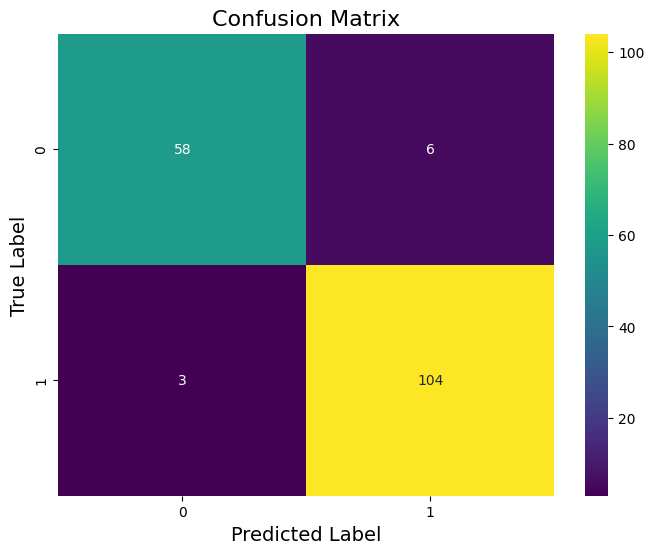

In [15]:
conf_mat = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='viridis', cbar=True)
plt.xlabel("Predicted Label", fontsize=14)
plt.ylabel("True Label", fontsize=14)
plt.title("Confusion Matrix", fontsize=16)
plt.show()

## 极端随机森林模型的优缺点

### 优点

- **训练速度快**：极端随机森林在构造决策树时引入了更多随机性，减少了寻找最佳分裂点的时间，因此在大数据集上训练速度通常较快。
- **抗过拟合能力强**：通过对样本和特征的随机抽样以及随机阈值的选择，模型在一定程度上降低了过拟合风险，具有较好的泛化性能。
- **特征重要性评估**：该模型内置特征重要性评估机制，可以直观地反映每个特征对决策的贡献，便于后续特征筛选与工程。
- **鲁棒性**：在存在噪声数据或存在缺失值的场景下，决策树集成方法通常比单棵树更为稳定和鲁棒。
- **无需数据归一化**：与基于距离或内积的模型不同，决策树算法对数据的缩放和归一化不敏感，可以直接处理原始数据。

### 缺点

- **解释性相对较弱**：虽然可以输出特征重要性，但整体模型为“黑箱”结构，单棵树的分裂路径较难解释整个模型的预测过程。
- **内存消耗较大**：构建大量树模型时，可能会消耗较多内存资源，尤其是在数据维度和样本数量较大时。
- **参数调优复杂**：虽然模型具有很多超参数（例如树的数量、最大深度、最小分裂样本数等），但这些参数之间的相互影响较大，调优过程可能较为耗时。
- **对异常点敏感**：决策树在某些情况下对异常值较为敏感，尤其是当异常点在少数决策树中引入错误分裂时，可能会影响整体模型表现。

## 何时优选极端随机森林，何时考虑其他算法

### 优选极端随机森林的情况

- **大规模数据处理**：在数据量较大、特征维度较高的情况下，由于其训练速度快且具有较强的鲁棒性，极端随机森林是一种理想选择。
- **对模型稳定性要求高**：当任务中噪声较多或样本质量不高时，该模型的随机化策略可以帮助提高整体稳定性。
- **需要快速迭代**：在开发和调试阶段，能够迅速得到模型评估结果，便于后续的特征筛选和算法改进。
- **解释性需求有限**：当重点在于提高预测准确性，而对模型解释要求不高时，极端随机森林可作为首选算法。

### 考虑其他算法的情况

- **追求极致性能**：当对模型预测性能有更高要求，并且能够投入更多计算资源进行调参时，XGBoost、LightGBM 或 GBDT 可能提供更高的精度。
- **解释性要求较高**：如果项目需要对模型内部决策路径进行详细解释或需要稀疏性较高的特征选择，则可能需要考虑更易解释的模型或结合其他解释性方法。
- **资源受限的场景**：在内存和计算资源受限的场景下，有时极端随机森林可能因大量树模型带来较高内存消耗，此时可以考虑简化的决策树或经过剪枝的随机森林。
- **不平衡数据处理**：当数据存在严重类别不平衡问题时，可能需要结合专门处理不平衡问题的算法或引入样本加权、欠采样/过采样策略，部分提升模型效果。